In [1]:
# =========================================================
# INSTALAÇÃO DOS PACOTES
# =========================================================

install.packages("tidyverse")
install.packages("naniar")
install.packages("visdat")
install.packages("MissMech")
install.packages("corrplot")
install.packages("mice")
install.packages("psych")
install.packages("skimr")
install.packages("Rdpack")

Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'tidyverse' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMBy1H9\downloaded_packages


Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'naniar' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMBy1H9\downloaded_packages


Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



...

package 'psych' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMBy1H9\downloaded_packages


Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'skimr' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMBy1H9\downloaded_packages


Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'Rdpack' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMBy1H9\downloaded_packages


In [14]:
install.packages("lubridate")

Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)

instalando a dependência 'timechange' também




package 'timechange' successfully unpacked and MD5 sums checked
package 'lubridate' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMBy1H9\downloaded_packages


In [3]:
# =========================================================
# CARREGAR PACOTES
# =========================================================

library(tidyverse)

# glimpse()
library(dplyr)
library(tidyr)
library(ggplot2)
library(readr)

# visualização de missing
library(naniar)
library(visdat)

# teste MCAR de Little
library(MissMech)

# correlogramas
library(corrplot)

# imputação múltipla
library(mice)

# análises psicométricas futuras
library(psych)

# relatórios descritivos
library(skimr)

corrplot 0.95 loaded


Anexando pacote: 'mice'


O seguinte objeto é mascarado por 'package:stats':

    filter


Os seguintes objetos são mascarados por 'package:base':

    cbind, rbind



Anexando pacote: 'psych'


Os seguintes objetos são mascarados por 'package:ggplot2':

    %+%, alpha



Anexando pacote: 'skimr'


O seguinte objeto é mascarado por 'package:naniar':

    n_complete




In [15]:
library(lubridate)


Anexando pacote: 'lubridate'


Os seguintes objetos são mascarados por 'package:base':

    date, intersect, setdiff, union




### ETAPA 1 — BASE DE DADOS

In [4]:
# =========================================================
# IMPORTAR BASE
# =========================================================

onet <- read.csv(
  "onet-v6.txt",
  check.names = FALSE
)

# Manter apenas linhas com Type == "Skills"
onet <- onet[onet$Type == "Skills" & onet$`Scale ID` == "LV", ]

onet$`Element Name`[
  onet$`Element ID` == "2.B.3.g"
] <- "Operations Monitoring"

### ETAPA 2 — CRIAR IDENTIFICADOR ÚNICO

In [5]:
onet <- onet %>%
  mutate(
    `Element and Scale` =
      paste(
        `Element Name`,
        `Scale Name`,
        sep = " - "
      )
  )

### ETAPA 3 — Z-SCORE POR SCALE ID

In [6]:
onet <- onet %>%
  group_by(`Scale ID`) %>%
  mutate(
    z_Data_Value =
      as.numeric(
        scale(`Data Value`)
      )
  ) %>%
  ungroup()

In [59]:
summary(onet$z_Data_Value)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-1.8469 -0.7451  0.1492  0.0000  0.6442  3.0394 

### ETAPA 3.5 — COBERTURA LONGITUDINAL

In [16]:
onet <- onet %>%
  mutate(
    Date = dmy(paste0("01/", Date)),
    Period = year(Date)
  )

Period,ocupacoes,skills
<dbl>,<int>,<int>
2010,170,35
2011,76,35
2012,62,35
2013,80,35
2014,82,35
2015,76,35
2016,87,35
2017,85,35
2018,74,35


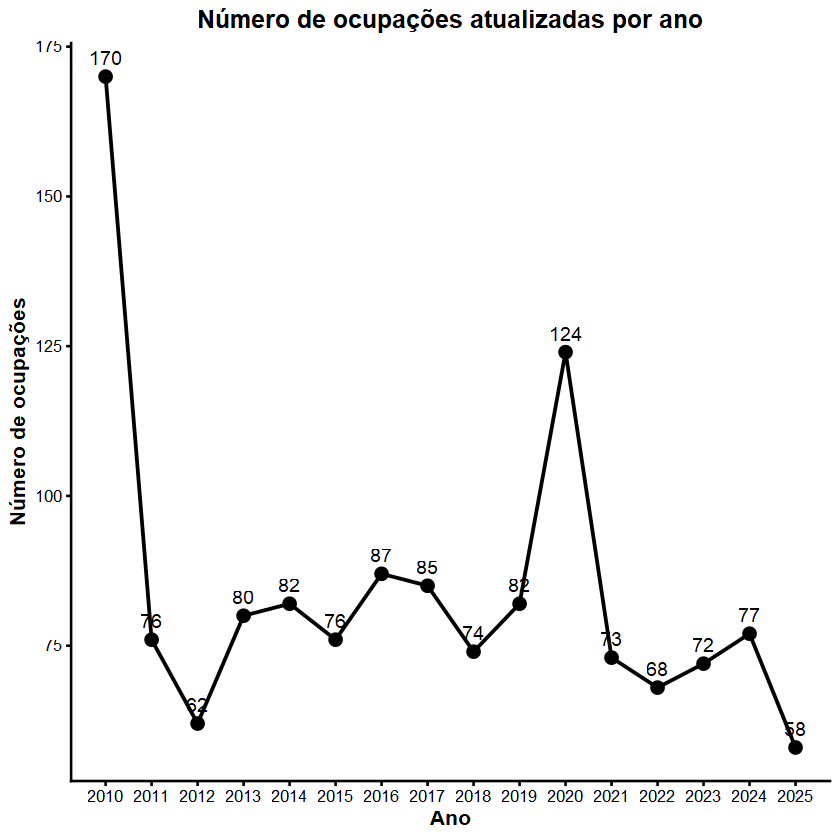

In [41]:
# =========================================================
# COBERTURA LONGITUDINAL
# =========================================================

coverage_year <- onet %>%
  group_by(`Period`) %>%
  summarise(
    ocupacoes = n_distinct(`O*NET-SOC Code`),
    skills = n_distinct(`Element and Scale`)
  )

coverage_year

ggplot(
  coverage_year,
  aes(
    x = Period,
    y = ocupacoes
  )
) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 3) +
  geom_text(
    aes(label = ocupacoes),
    vjust = -0.8,
    size = 4
  ) +
  scale_x_continuous(
    breaks = coverage_year$Period
  ) +
  labs(
    title = "Número de ocupações atualizadas por ano",
    x = "Ano",
    y = "Número de ocupações"
  ) +
  theme_classic(base_size = 12) +
  theme(
    plot.title = element_text(
      hjust = 0.5,
      face = "bold"
    ),
    axis.title = element_text(face = "bold")
  )

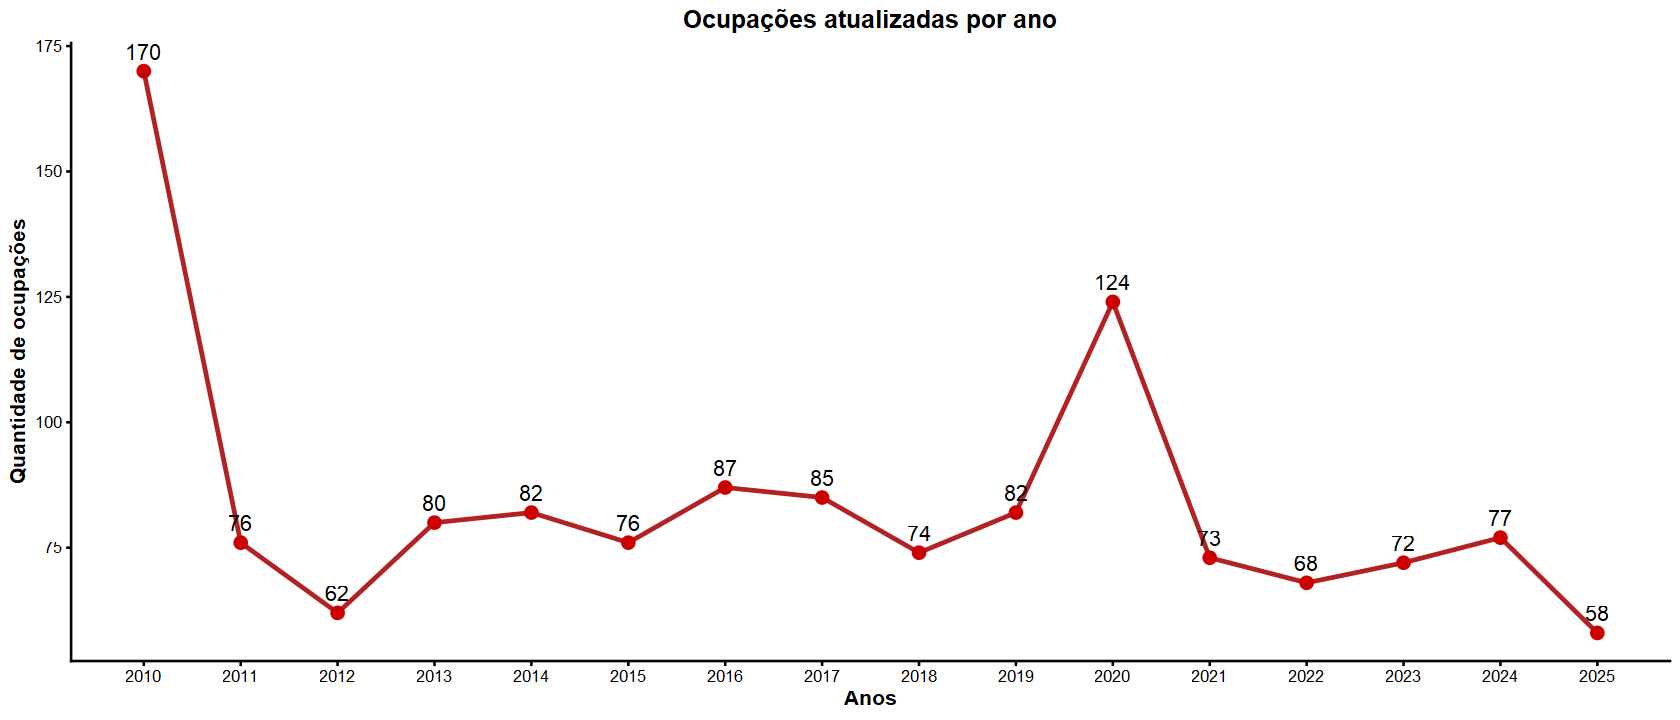

In [57]:
options(
  repr.plot.width = 14,
  repr.plot.height = 6
)

ggplot(
  coverage_year,
  aes(
    x = Period,
    y = ocupacoes
  )
) +
  geom_line(
    linewidth = 1,
    color = "firebrick"
  ) +
  geom_point(
    size = 3,
    color = "red3"
  ) +
  geom_text(
    aes(label = ocupacoes),
    vjust = -0.7,
    size = 4.5

  ) +
  scale_x_continuous(
    breaks = coverage_year$Period
  ) +
  labs(
     title = "Ocupações atualizadas por ano",
    x = "Anos",
    y = "Quantidade de ocupações"
  ) +
  theme_classic(base_size = 12) +
  theme(
    plot.title = element_text(
      hjust = 0.5,
      face = "bold"
    ),
    axis.title = element_text(face = "bold")
  )

### ETAPA 4 — CONSTRUIR PAINEL LONGITUDINAL

In [29]:
anos_disponiveis <-
  sort(
    unique(
      onet$`Version Year`
    )
  )

anos_disponiveis

[1] 2017 2019 2021 2023 2025

In [30]:
occ_long <- onet %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_years =
      n_distinct(`Version Year`)
  ) %>%
  filter(
    n_years ==
      length(anos_disponiveis)
  )

In [31]:
sample_long <- onet %>%
  filter(
    `O*NET-SOC Code`
    %in%
    occ_long$`O*NET-SOC Code`
  )

In [32]:
retention_report <- tibble(

  indicador = c(
    "Ocupações originais",
    "Ocupações longitudinais"
  ),

  valor = c(
    n_distinct(
      onet$`O*NET-SOC Code`
    ),
    n_distinct(
      sample_long$`O*NET-SOC Code`
    )
  )
)

retention_report

indicador,valor
<chr>,<int>
Ocupações originais,798
Ocupações longitudinais,610


In [65]:
100 *
n_distinct(
  sample_long$`O*NET-SOC Code`
) /
n_distinct(
  onet$`O*NET-SOC Code`
)

[1] 76.4411

In [66]:
balance_check <- sample_long %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    anos =
      n_distinct(
        `Version Year`
      ),
    .groups = "drop"
  )

summary(balance_check$anos)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      5       5       5       5       5       5 

### ETAPA 5 — TRANSFORMAR PARA WIDE

In [33]:
panel_wide <- sample_long %>%
  select(
    `O*NET-SOC Code`,
    Title,
    `Version Year`,
     `Year`,
      `Period`,
    `Element and Scale`,
    z_Data_Value
  ) %>%
  pivot_wider(
    names_from =
      `Element and Scale`,
    values_from =
      z_Data_Value,
    values_fn =
      mean
  )

In [34]:
dim(panel_wide)

[1] 3050   40

### ETAPA 6 — RELATÓRIO DE MISSING

In [87]:
global_missing <-
  mean(
    is.na(panel_wide)
  ) * 100

global_missing

[1] 0.2450388

In [88]:
missing_var <- panel_wide %>%
  summarise(
    across(
      everything(),
      ~ mean(is.na(.))*100
    )
  ) %>%
  pivot_longer(
    everything(),
    names_to =
      "variable",
    values_to =
      "missing_pct"
  ) %>%
  arrange(
    desc(missing_pct)
  )

In [99]:
head(missing_var,35)

variable,missing_pct
<chr>,<dbl>
Operations Analysis - Level,2.26229508
Technology Design - Level,1.08196721
Programming - Level,1.04918033
Installation - Level,0.75409836
Quality Control Analysis - Level,0.68852459
Science - Level,0.49180328
Management of Financial Resources - Level,0.49180328
Equipment Selection - Level,0.49180328
Mathematical Reasoning - Level,0.36065574


In [37]:
missing_year <- panel_wide %>%
  group_by(`Period`) %>%
  summarise(
    missing_pct =
      mean(
        is.na(across(everything()))
      )*100
  )

In [38]:
missing_year

Period,missing_pct
<dbl>,<dbl>
2010,1.62393162
2011,0.26862027
2012,0.97572044
2013,0.17510944
2014,0.14513788
2015,0.11288502
2016,0.03384954
2017,0.02564103
2018,0.06357279


### ETAPA 7 — VISUALIZAÇÕES

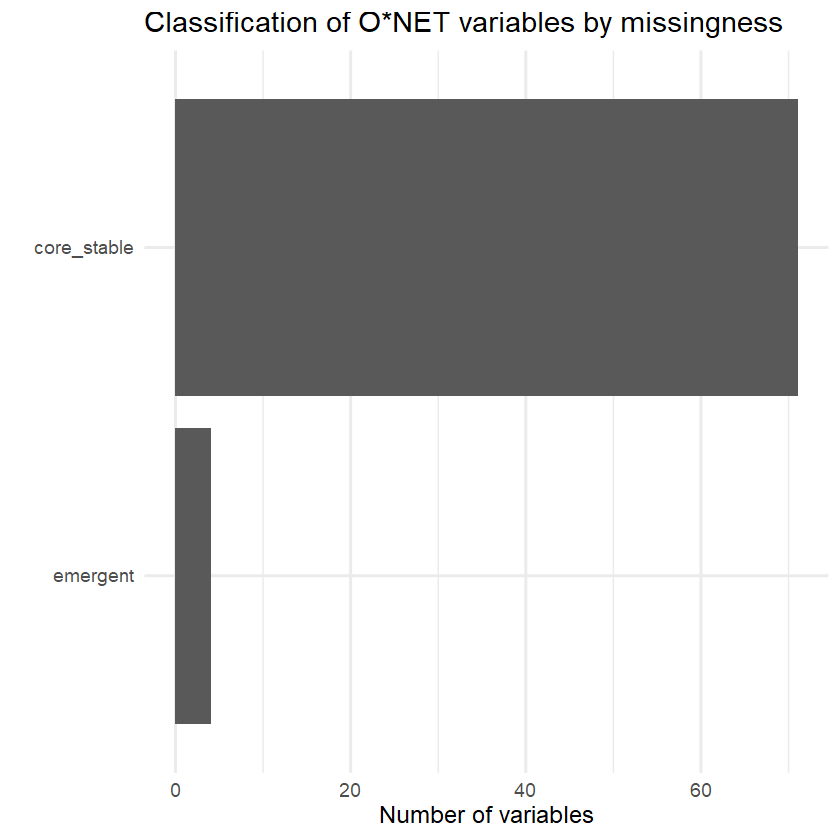

In [74]:
ggplot(
  classification_report,
  aes(
    x = reorder(categoria, n),
    y = n
  )
) +
  geom_col() +
  coord_flip() +
  theme_minimal(base_size = 14) +
  labs(
    title = "Classification of O*NET variables by missingness",
    x = "",
    y = "Number of variables"
  )

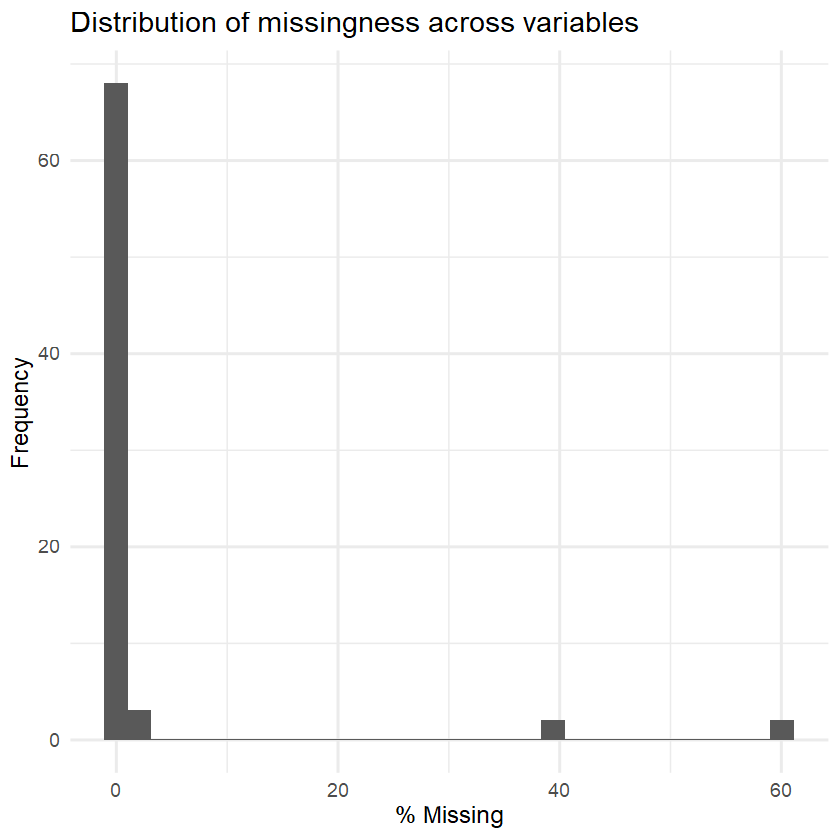

In [75]:
ggplot(
  classified_vars,
  aes(x = missing_pct)
) +
  geom_histogram(
    bins = 30
  ) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Distribution of missingness across variables",
    x = "% Missing",
    y = "Frequency"
  )

In [76]:
top_missing <- classified_vars %>%
  slice_max(
    missing_pct,
    n = 30
  )

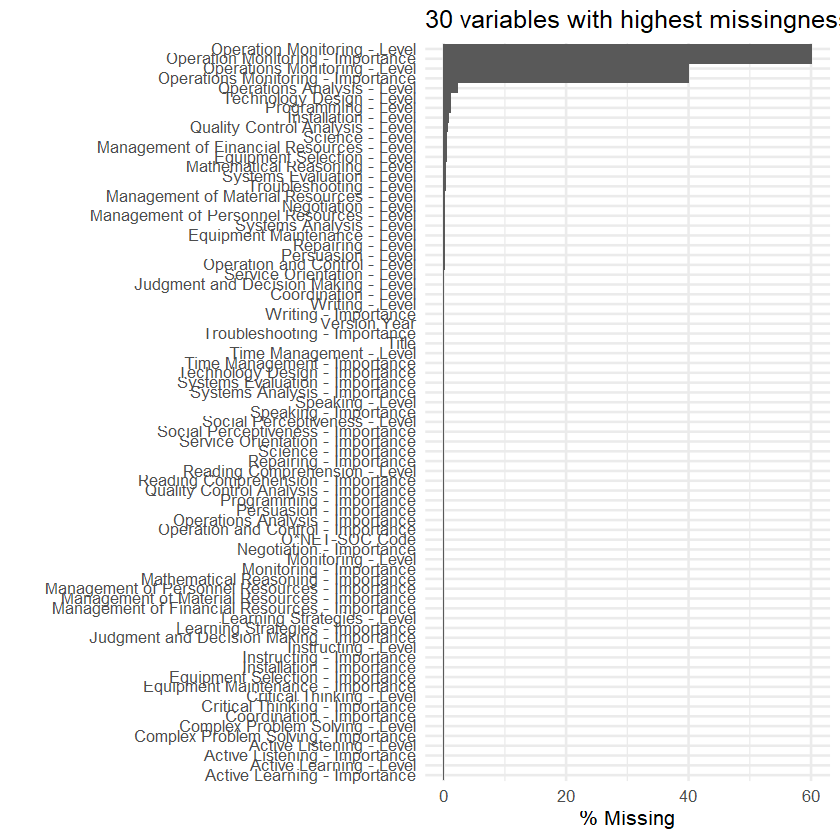

In [77]:
ggplot(
  top_missing,
  aes(
    x = reorder(variable, missing_pct),
    y = missing_pct
  )
) +
  geom_col() +
  coord_flip() +
  theme_minimal(base_size = 12) +
  labs(
    title = "30 variables with highest missingness",
    x = "",
    y = "% Missing"
  )

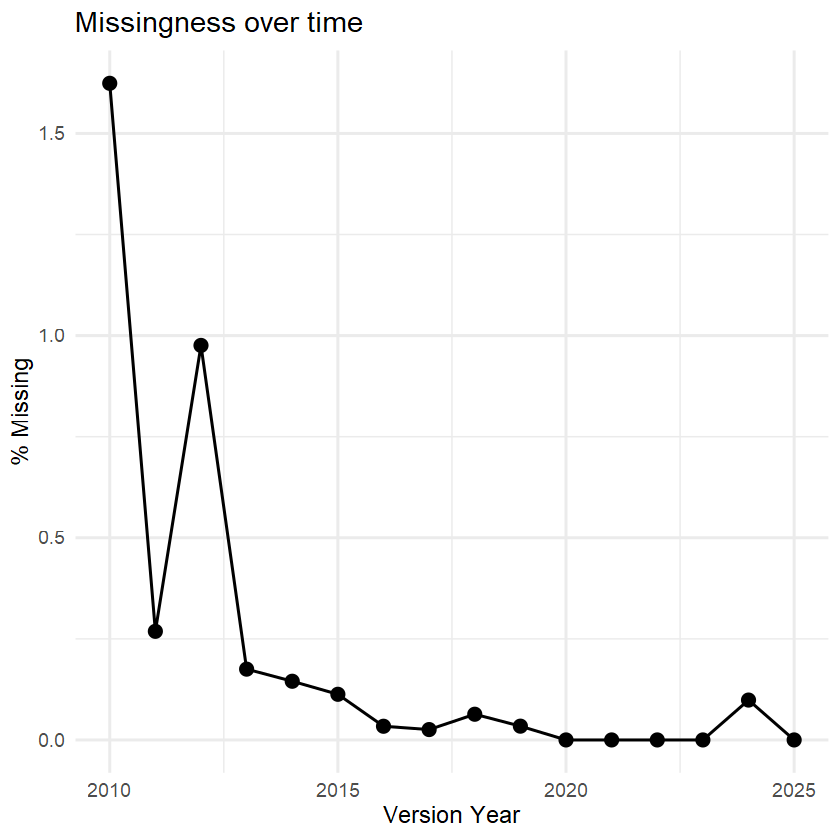

In [39]:
ggplot(
  missing_year,
  aes(
    x = `Period`,
    y = missing_pct
  )
) +
  geom_line() +
  geom_point(size = 3) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Missingness over time",
    x = "Version Year",
    y = "% Missing"
  )

In [40]:
quality_report <- tibble(

  Metric = c(
    "Original occupations",
    "Balanced-panel occupations",
    "Retention (%)",
    "Years",
    "Variables",
    "Observations"
  ),

  Value = c(
    798,
    610,
    round(610/798*100,2),
    length(unique(panel_wide$`Version Year`)),
    ncol(panel_wide)-3,
    nrow(panel_wide)
  )
)

quality_report

Metric,Value
<chr>,<dbl>
Original occupations,798.00
Balanced-panel occupations,610.00
Retention (%),76.44
Years,5.00
Variables,37.00
Observations,3050.00


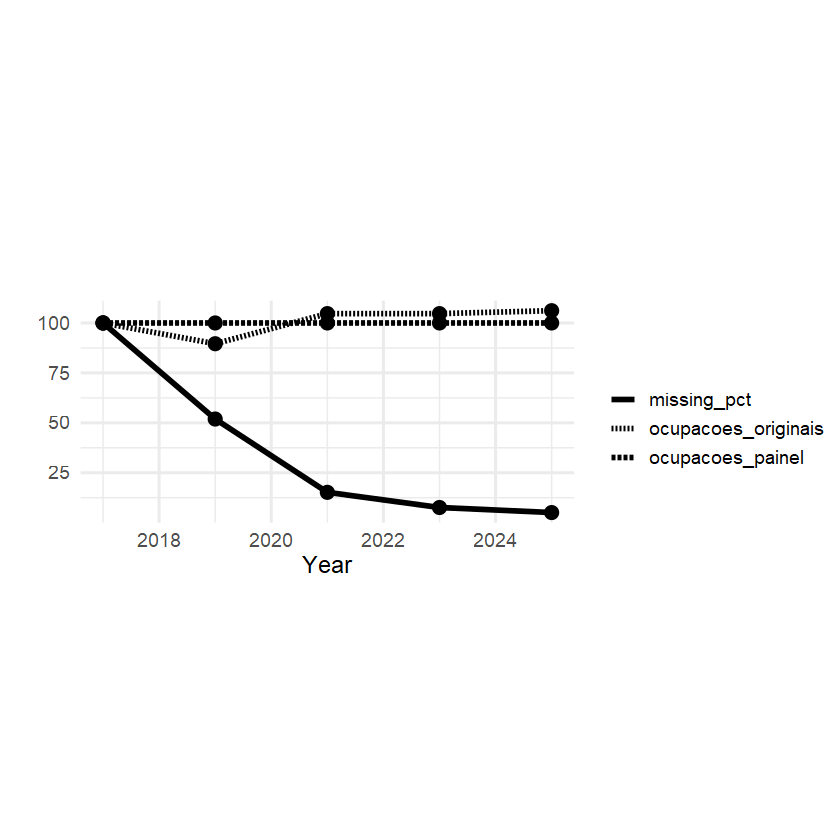

In [94]:
# =========================================================
# GRÁFICO LONGITUDINAL - ÍNDICE BASE 100
# =========================================================

occupations_year <- onet %>%
  group_by(`Version Year`) %>%
  summarise(
    ocupacoes_originais =
      n_distinct(`O*NET-SOC Code`),
    .groups = "drop"
  )

balanced_year <- sample_long %>%
  group_by(`Version Year`) %>%
  summarise(
    ocupacoes_painel =
      n_distinct(`O*NET-SOC Code`),
    .groups = "drop"
  )

plot_data <- occupations_year %>%
  left_join(
    balanced_year,
    by = "Version Year"
  ) %>%
  left_join(
    missing_year,
    by = "Version Year"
  ) %>%
  mutate(

    ocupacoes_originais =
      ocupacoes_originais /
      first(ocupacoes_originais) * 100,

    ocupacoes_painel =
      ocupacoes_painel /
      first(ocupacoes_painel) * 100,

    missing_pct =
      missing_pct /
      first(missing_pct) * 100
  ) %>%
  pivot_longer(
    -`Version Year`,
    names_to = "serie",
    values_to = "indice"
  )

ggplot(
  plot_data,
  aes(
    x = `Version Year`,
    y = indice,
    group = serie,
    linetype = serie
  )
) +
  geom_line(
    linewidth = 1.2
  ) +
  geom_point(
    size = 3
  ) +
  theme_minimal(base_size = 14) +
  theme(
    aspect.ratio = 0.45
  ) +
  labs(
    title = "",
    x = "Year",
    y = "",
    linetype = ""
  )

### ETAPA 8 — CLASSIFICAÇÃO DAS VARIÁVEIS

In [95]:
classified_vars <- missing_var %>%
  mutate(
    categoria =
      case_when(

        missing_pct <= 5 ~
          "core_stable",

        missing_pct <= 30 ~
          "transitional",

        missing_pct <= 70 ~
          "emergent",

        TRUE ~
          "sparse"
      )
  )

In [96]:
classification_report <- classified_vars %>%
  count(categoria) %>%
  mutate(
    percentual =
      round(
        n/sum(n)*100,
        2
      )
  ) %>%
  arrange(desc(n))

classification_report

categoria,n,percentual
<chr>,<int>,<dbl>
core_stable,38,100


### ETAPA 9 — MATRIZ FINAL

In [97]:
valid_vars <- classified_vars %>%
  filter(
    categoria != "sparse"
  ) %>%
  pull(variable)

### ETAPA 10 — EXPORTAÇÃO

In [36]:
write.table(
  panel_wide,
  "missing-d.txt",
  sep = "\t",
  quote = FALSE,
  row.names = FALSE,
  fileEncoding = "UTF-8"
)

In [35]:
panel_wide

O*NET-SOC Code,Title,Version Year,Year,Period,Reading Comprehension - Level,Active Listening - Level,Writing - Level,Speaking - Level,Mathematical Reasoning - Level,⋯,Repairing - Level,Quality Control Analysis - Level,Judgment and Decision Making - Level,Systems Analysis - Level,Systems Evaluation - Level,Time Management - Level,Management of Financial Resources - Level,Management of Material Resources - Level,Management of Personnel Resources - Level,Equipment Selection - Level
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11-1011.00,Chief Executives,2017,2016,2014,1.9455772,2.0493705,1.6501653,2.049370,1.04337347,⋯,-1.846872,-1.04846160,2.7439875,2.44857566,2.24098897,1.9455772,2.5443849,1.94557715,2.4485757,NA
11-1021.00,General and Operations Managers,2017,2016,2015,1.3467694,1.3467694,1.2509602,1.346769,0.14915390,⋯,-1.846872,-0.15424203,1.1471668,0.54835907,0.64416831,1.1471668,0.8517550,0.74796165,1.2509602,-1.8468719
11-2011.00,Advertising and Promotions Managers,2017,2016,2010,1.4425786,1.4425786,1.2509602,1.650165,0.64416831,⋯,-1.846872,NA,1.4425786,0.85175499,1.14716682,1.3467694,1.1471668,0.24496314,1.3467694,-1.4476668
11-2021.00,Marketing Managers,2017,2016,2015,1.5463720,1.4425786,1.2509602,1.442579,0.64416831,⋯,-1.846872,-0.74506567,1.3467694,1.14716682,1.14716682,1.1471668,1.1471668,0.34875648,1.2509602,-1.8468719
11-2022.00,Sales Managers,2017,2016,2016,1.3467694,1.3467694,1.3467694,1.442579,0.74796165,⋯,-1.846872,-0.74506567,1.3467694,1.14716682,1.25096016,1.2509602,1.0433735,0.54835907,1.3467694,-1.8468719
11-3021.00,Computer and Information Systems Managers,2017,2016,2016,1.3467694,1.3467694,1.3467694,1.250960,0.64416831,⋯,-1.248064,0.54835907,1.1471668,0.94756423,1.25096016,1.1471668,0.8517550,0.64416831,1.1471668,-0.2500513
11-3051.00,Industrial Production Managers,2017,2016,2013,1.5463720,1.4425786,1.2509602,1.346769,0.94756423,⋯,-0.848859,1.14716682,1.7459746,1.25096016,1.14716682,1.4425786,1.3467694,1.34676940,1.6501653,-0.4496538
11-3061.00,Purchasing Managers,2017,2016,2010,1.3467694,1.4425786,1.3467694,1.346769,0.94756423,⋯,-1.846872,0.54835907,1.2509602,1.14716682,1.14716682,1.2509602,1.6501653,1.25096016,1.5463720,-1.8468719
11-3111.00,Compensation and Benefits Managers,2017,2017,2017,1.3467694,1.4425786,1.3467694,1.346769,0.45254983,⋯,-1.846872,-1.24806418,1.3467694,1.25096016,1.25096016,1.2509602,1.0433735,-0.25005127,0.9475642,-1.8468719


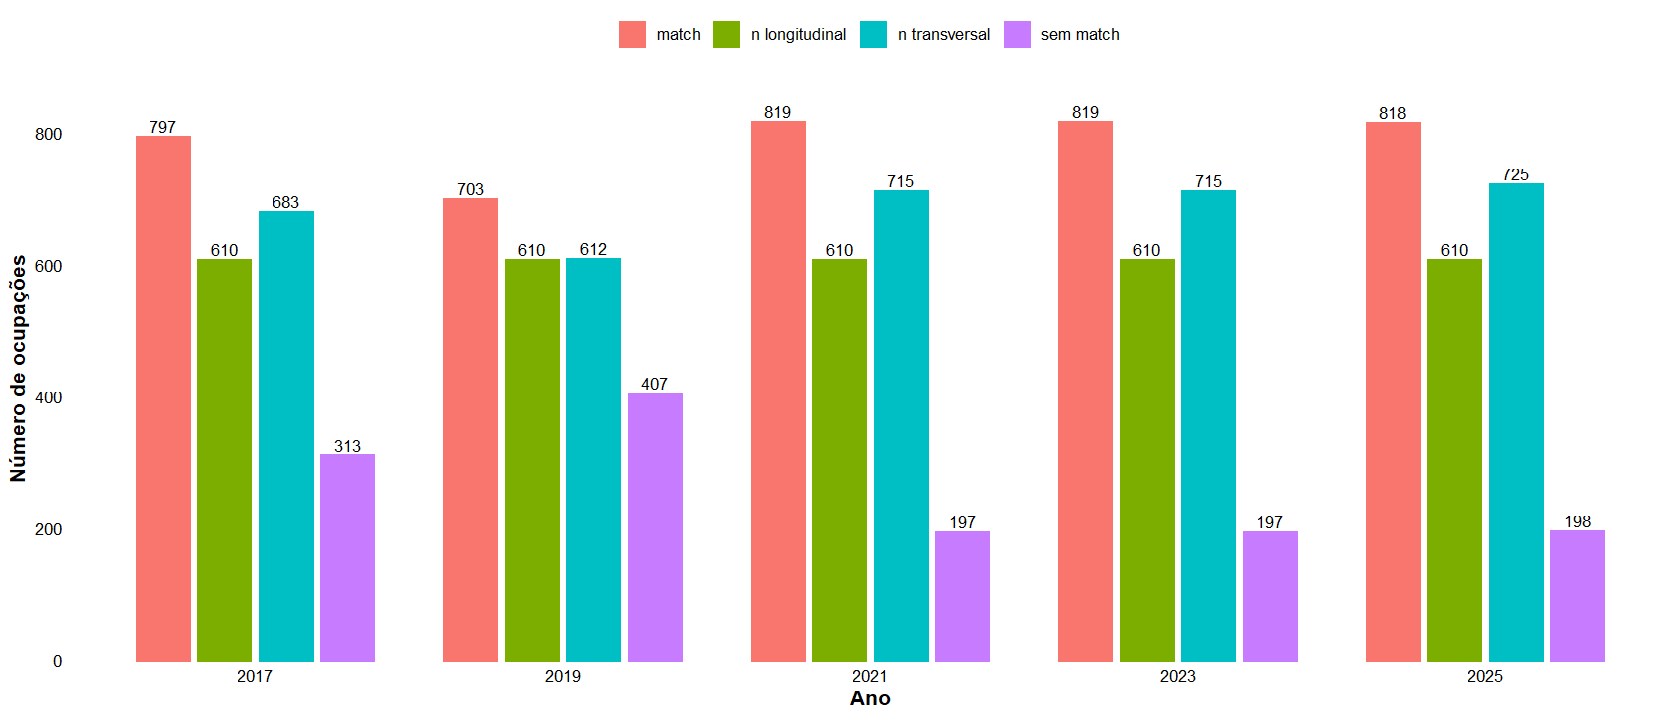

In [59]:
#---------------------------------------
# Dados
#---------------------------------------

dados <- tribble(
  ~ano, ~match, ~`sem match`, ~`n transversal`, ~`n longitudinal`,
  2017, 797, 313, 683, 610,
  2019, 703, 407, 612, 610,
  2021, 819, 197, 715, 610,
  2023, 819, 197, 715, 610,
  2025, 818, 198, 725, 610
)

# formato longo
dados_long <- dados %>%
  pivot_longer(
    cols = -ano,
    names_to = "categoria",
    values_to = "ocupacoes"
  )

#---------------------------------------
# Gráfico
#---------------------------------------

ggplot(
  dados_long,
  aes(
    x = factor(ano),
    y = ocupacoes,
    fill = categoria
  )
) +
  geom_col(
    position = position_dodge(width = 0.8),
    width = 0.7
  ) +
  geom_text(
    aes(label = ocupacoes),
    position = position_dodge(width = 0.8),
    vjust = -0.25,
    size = 3.5
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, .08))
  ) +
  labs(
    x = "Ano",
    y = "Número de ocupações",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
    theme(
      legend.position = "top",
      legend.direction = "horizontal",
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      axis.title = element_text(face = "bold"),
      axis.text = element_text(color = "black")
    )